In [1]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
model = keras.models.load_model("best_lstm_model (1).keras")

In [4]:
test_df = pd.read_csv("test.csv").set_index("Datetime")

In [5]:
TARGET = "Global_active_power_mean"

DROPS = [
    "Global_active_power_mean",
    "Global_active_power_max",
    "Global_active_power_min",
    "Global_active_power_std",
    # "Global_intensity_mean",
    "Global_intensity_max",
    "Global_intensity_min",
    "Global_intensity_std",
    "Voltage_max",
    "Voltage_min",
    "Voltage_std",
    "lag_168",
    "roll_std_24h",
    "roll_mean_168h",
    "roll_std_168h",
    "roll_mean_6h",
    "roll_std_6h",
    "Sub_metering_1_max",
    "Sub_metering_1_min",
    # 'Sub_metering_1_std',
    'Sub_metering_2_max',
    'Sub_metering_2_min',
    # 'Sub_metering_2_std',
    'Sub_metering_3_max',
    'Sub_metering_3_min',
    # 'Sub_metering_3_std',
    # 'hour_sin',
    # 'hour_cos',
    'dow_sin',
    'dow_cos',
    'month_sin',
    'month_cos',
    'is_weekend'
]

In [6]:
scaler = MinMaxScaler()

X_test = test_df.drop(columns=DROPS)
y_test = test_df[TARGET]

X_test_scaled = pd.DataFrame(
    scaler.fit_transform(X_test),
    index=X_test.index,
    columns=X_test.columns,
)

def make_windows(X, y, window):
    Xs, ys = [], []

    for i in range(window, len(X)):
        Xs.append(X.iloc[i-window:i].values)
        ys.append(y.iloc[i])

    return np.array(Xs), np.array(ys)

WINDOW = 48
Xte, yte = make_windows(X_test_scaled, y_test, WINDOW)

In [7]:
y_pred = model.predict(Xte).ravel()
y_true = yte
y_pred

160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step


array([0.7238483 , 0.99892664, 1.0210743 , ..., 2.3438635 , 2.350168  ,
       1.3756399 ], shape=(5116,), dtype=float32)

In [8]:
len(test_df)

5164

In [9]:
aligned_test_df = test_df.iloc[-len(y_pred):].copy()
aligned_test_df["y_pred"] = y_pred

aligned_test_df.head()

,Global_active_power_mean,Global_active_power_max,Global_active_power_min,Global_active_power_std,Voltage_mean,Voltage_max,Voltage_min,Voltage_std,Global_intensity_mean,Global_intensity_max,...,lag_1,lag_24,lag_168,roll_mean_6h,roll_std_6h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h,y_pred
Datetime,,,,,,,,,,,,,,,,,,,,,
2010-04-27 18:00:00,0.413533,0.978,0.240,0.245372,241.901333,244.24,239.23,1.050300,1.746667,4.2,...,0.338167,0.485133,1.255633,0.711744,0.468161,1.067822,0.523017,0.990124,0.661003,0.723848
2010-04-27 19:00:00,0.338700,0.488,0.242,0.073877,241.776667,244.75,239.82,1.214592,1.460000,2.4,...,0.413533,1.483033,1.406000,0.525528,0.247320,1.064839,0.526676,0.985112,0.662170,0.998927
2010-04-27 20:00:00,0.415300,1.034,0.312,0.158393,242.357667,244.32,239.70,1.124518,1.830000,4.4,...,0.338700,1.464300,2.415400,0.412306,0.065213,1.017158,0.538829,0.978759,0.663227,1.021074
2010-04-27 21:00:00,0.349700,0.982,0.242,0.166957,242.771667,244.61,240.25,1.160197,1.466667,4.2,...,0.415300,1.425767,2.270567,0.397089,0.046887,0.973450,0.543507,0.966853,0.655186,0.996833
2010-04-27 22:00:00,0.443133,1.566,0.246,0.354283,244.746500,246.52,242.43,1.315342,1.830000,6.4,...,0.349700,2.184333,1.423533,0.381167,0.043356,0.928614,0.548929,0.955419,0.649031,0.742695


In [16]:
aligned_test_df.to_csv("predictions.csv", index_label="Datetime")

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")


MAE  : 0.3239
RMSE : 0.4607
MAPE : 44.62%
R²   : 0.5700


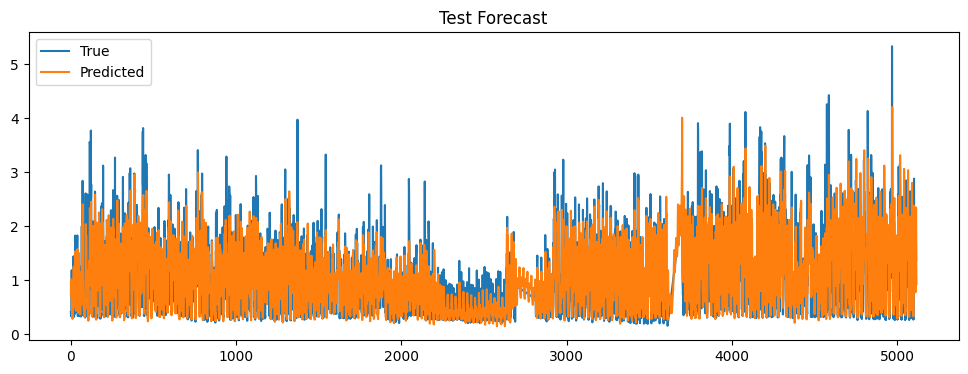

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y_true, label="True")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Test Forecast")
plt.show()
